# Baselines determinístico e preditivo — M3

Este notebook demonstra a política fixa de melhor canal histórico, o DummyClassifier e a Regressão Logística de propensão. O treino usa somente `train`, o limiar é escolhido em `validation` e `test` é usado apenas na avaliação final.

O modelo estima associação `P(conversão | contexto, canal observado)`. Nenhum resultado deste notebook representa efeito causal do canal.

In [1]:
import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Localiza a raiz do projeto sem depender do diretório inicial do kernel.
current_path = Path.cwd().resolve()
project_root = current_path if (current_path / "configs").exists() else current_path.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.models.train_propensity import (
    PROPENSITY_INPUT_COLUMNS,
    load_modeling_config,
    load_processed_splits,
    run_m3_training,
)

modeling_config_path = project_root / "configs" / "modeling.yaml"
sns.set_theme(style="whitegrid", palette="deep")

## 1. Execução reproduzível

A execução abaixo regenera os relatórios sem abrir um novo run no MLflow. O run oficial é criado pelo comando de linha de comando documentado no README.

In [2]:
m3_report = run_m3_training(modeling_config_path, enable_tracking=False)
modeling_config = load_modeling_config(modeling_config_path)
splits, preparation_metadata = load_processed_splits(modeling_config)

pd.Series(
    {
        "marco": m3_report["milestone"],
        "modelo_selecionado": m3_report["selection"]["selected_model"],
        "gate_superou_dummy": m3_report["selection"]["gate_passed"],
        "features_transformadas": m3_report["contracts"]["transformed_feature_count"],
    }
)

marco                                      M3
modelo_selecionado        logistic_propensity
gate_superou_dummy                       True
features_transformadas                     29
dtype: object

## 2. Baseline determinístico

In [3]:
fixed_statistics = pd.DataFrame(m3_report["fixed_policy"]["statistics"])
fixed_statistics

,action,observations,conversions,conversion_rate,confidence_interval_lower,confidence_interval_upper
0,celular,18313,2699,0.147382,0.142321,0.152590
1,telefone,10510,548,0.052141,0.048052,0.056557


In [4]:
replay_summary = pd.DataFrame(
    [
        {"split": split_name, **metrics}
        for split_name, metrics in m3_report["fixed_policy"]["replay"].items()
    ]
)[
    [
        "split",
        "recommended_action",
        "accepted_events",
        "replay_coverage",
        "conversions",
        "mean_reward",
    ]
]
replay_summary

,split,recommended_action,accepted_events,replay_coverage,conversions,mean_reward
0,validation,celular,3924,0.635363,561,0.142966
1,test,celular,3898,0.631051,592,0.151873


`celular` é congelado como melhor braço usando somente o treino. No replay, a recompensa existe apenas quando a recomendação coincide com o canal histórico; por isso, taxa de recompensa e cobertura devem ser apresentadas juntas.

## 3. Dummy versus Regressão Logística

In [5]:
comparison_rows = []
for model_name in ["dummy", "logistic_regression"]:
    for split_name in ["validation", "test"]:
        metrics = m3_report["predictive_models"][model_name][split_name]
        comparison_rows.append(
            {
                "modelo": model_name,
                "split": split_name,
                "pr_auc": metrics["average_precision"],
                "roc_auc": metrics["roc_auc"],
                "brier": metrics["brier_score"],
                "f1": metrics["f1"],
                "recall": metrics["recall"],
                "precision": metrics["precision"],
            }
        )
model_comparison = pd.DataFrame(comparison_rows)
model_comparison

,modelo,split,pr_auc,roc_auc,brier,f1,recall,precision
0,dummy,validation,0.112694,0.500000,0.099994,0.000000,0.000000,0.000000
1,dummy,test,0.112676,0.500000,0.099980,0.000000,0.000000,0.000000
2,logistic_regression,validation,0.449334,0.795413,0.078972,0.490898,0.561782,0.435897
3,logistic_regression,test,0.466352,0.812912,0.077059,0.505411,0.570402,0.453714


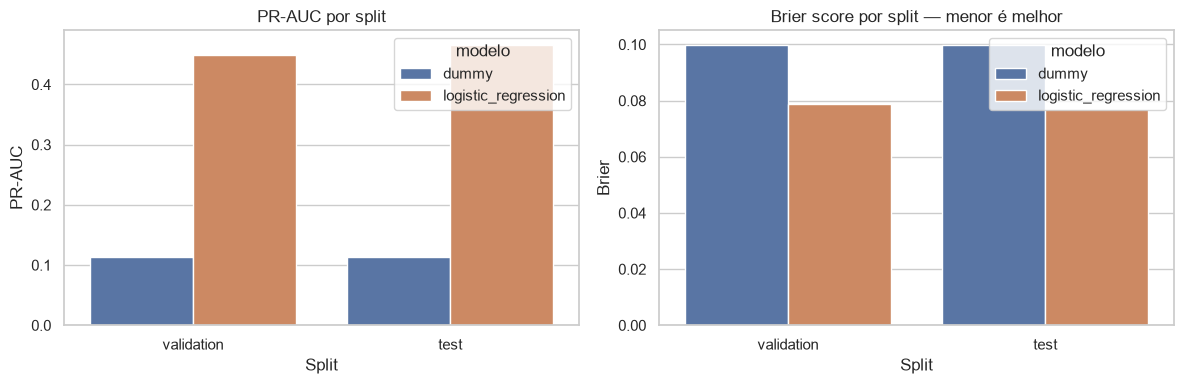

In [6]:
figure, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=model_comparison, x="split", y="pr_auc", hue="modelo", ax=axes[0])
axes[0].set(title="PR-AUC por split", xlabel="Split", ylabel="PR-AUC")
sns.barplot(data=model_comparison, x="split", y="brier", hue="modelo", ax=axes[1])
axes[1].set(title="Brier score por split — menor é melhor", xlabel="Split", ylabel="Brier")
plt.tight_layout()
plt.show()

PR-AUC é a métrica principal devido à prevalência positiva de aproximadamente 11,27%. A Regressão Logística também reduz o Brier score contra o Dummy, portanto um calibrador adicional não foi aplicado nesta baseline.

## 4. Limiar e matriz de confusão

In [7]:
logistic_report = m3_report["predictive_models"]["logistic_regression"]
threshold_summary = pd.Series(
    {
        "estrategia": "max_f1_on_validation",
        "limiar_congelado": logistic_report["threshold_selection"]["threshold"],
        "f1_validacao": logistic_report["validation"]["f1"],
        "f1_teste": logistic_report["test"]["f1"],
    }
)
threshold_summary

estrategia          max_f1_on_validation
limiar_congelado                0.204832
f1_validacao                    0.490898
f1_teste                        0.505411
dtype: object

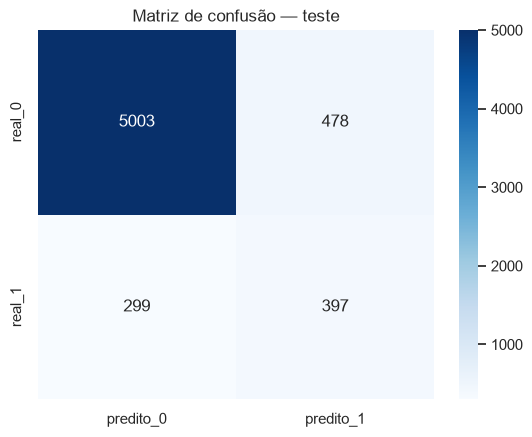

In [8]:
confusion = logistic_report["test"]["confusion_matrix"]
confusion_frame = pd.DataFrame(
    [
        [confusion["true_negatives"], confusion["false_positives"]],
        [confusion["false_negatives"], confusion["true_positives"]],
    ],
    index=["real_0", "real_1"],
    columns=["predito_0", "predito_1"],
)
sns.heatmap(confusion_frame, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusão — teste")
plt.show()

O limiar maximiza F1 na validação e é aplicado sem ajuste no teste. Ele é uma referência técnica; um limiar de produção deverá refletir custos de contato, capacidade e risco aprovados pelo negócio.

## 5. Calibração no teste

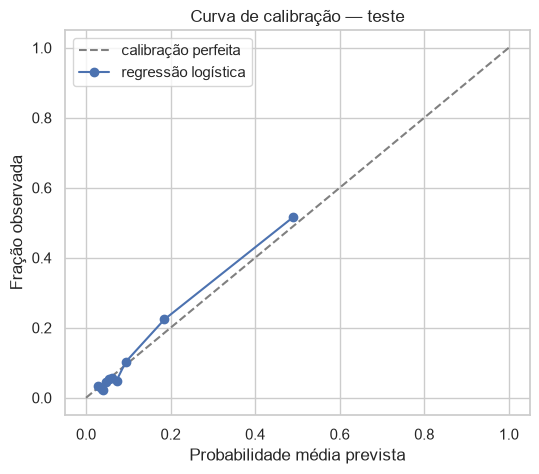

In [9]:
calibration_frame = pd.DataFrame(logistic_report["test"]["calibration_curve"])
figure, axis = plt.subplots(figsize=(6, 5))
axis.plot([0, 1], [0, 1], linestyle="--", color="gray", label="calibração perfeita")
axis.plot(
    calibration_frame["mean_predicted_probability"],
    calibration_frame["observed_fraction"],
    marker="o",
    label="regressão logística",
)
axis.set(
    title="Curva de calibração — teste",
    xlabel="Probabilidade média prevista",
    ylabel="Fração observada",
)
axis.legend()
plt.show()

## 6. Avaliação por fatias de auditoria

In [10]:
slice_metrics = pd.read_csv(modeling_config.test_slice_metrics_path)
slice_metrics.sort_values(["slice_column", "average_precision"], ascending=[True, False])

,slice_column,slice_value,row_count,positive_rate,average_precision,roc_auc,brier_score,precision,recall,f1
0,emprestimo_pessoal,nao,5124,0.119048,0.471271,0.809005,0.080895,0.465955,0.572131,0.513613
1,emprestimo_pessoal,sim,922,0.081345,0.455138,0.837835,0.057835,0.379630,0.546667,0.448087
2,emprestimo_pessoal,desconhecido,131,0.083969,0.384798,0.827273,0.062341,0.388889,0.636364,0.482759
3,escolaridade,desconhecido,273,0.146520,0.611819,0.879077,0.088369,0.562500,0.675000,0.613636
4,escolaridade,curso_profissionalizante,778,0.141388,0.584886,0.815562,0.084415,0.539683,0.618182,0.576271
5,escolaridade,ensino_superior,1821,0.138386,0.459002,0.808368,0.094247,0.438746,0.611111,0.510779
6,escolaridade,basico_4_anos,624,0.062500,0.458749,0.844335,0.045611,0.338462,0.564103,0.423077
7,escolaridade,ensino_medio,1429,0.105668,0.451579,0.805128,0.074476,0.445652,0.543046,0.489552
8,escolaridade,basico_6_anos,363,0.079890,0.396146,0.805183,0.059453,0.483871,0.517241,0.500000
9,escolaridade,basico_9_anos,888,0.084459,0.356993,0.761041,0.065424,0.414286,0.386667,0.400000


As 34 fatias com pelo menos 100 registros são avaliadas somente depois da predição. Esses campos não foram usados no treino. PR-AUC depende da prevalência de cada fatia; diferenças são sinais para investigação e não comprovam discriminação ou qualidade superior de um grupo.

## 7. Coeficientes e limites de interpretação

In [11]:
coefficient_frame = pd.read_csv(modeling_config.coefficients_path)
pd.concat([coefficient_frame.head(8), coefficient_frame.tail(8)])

,feature,coefficient,odds_ratio
0,mes_contato_mar,1.278944,3.592844
1,indice_precos_consumidor,1.021481,2.777306
2,euribor_3_meses,0.654793,1.924744
3,mes_contato_dez,0.315691,1.371207
4,mes_contato_ago,0.283800,1.328168
5,resultado_campanha_anterior_sucesso,0.176514,1.193051
6,canal_contato_celular,0.134316,1.143754
7,numero_empregados,0.119616,1.127063
21,dia_semana_seg,-0.294544,0.744871
22,resultado_campanha_anterior_fracasso,-0.580720,0.559496


Coeficientes descrevem associações condicionais do modelo regularizado e dependem da codificação/escala. Não devem ser convertidos em regras causais ou justificativas individuais. Campos demográficos e financeiros de auditoria não foram usados.

## 8. Reuso do pipeline treinado

In [12]:
model_artifact = joblib.load(modeling_config.model_path)
test_payload = splits["test"].loc[:, PROPENSITY_INPUT_COLUMNS].iloc[[0]]
smoke_probability = model_artifact["pipeline"].predict_proba(test_payload)[0, 1]

pd.Series(
    {
        "fit_split": model_artifact["fit_split"],
        "selection_split": model_artifact["selection_split"],
        "limiar": model_artifact["threshold"],
        "probabilidade_smoke_test": smoke_probability,
        "duration_presente": "duracao_contato" in model_artifact["input_columns"],
    }
)

fit_split                        train
selection_split             validation
limiar                        0.204832
probabilidade_smoke_test      0.031164
duration_presente                False
dtype: object

## 9. Tracking MLflow

In [13]:
tracking_path = modeling_config.latest_mlflow_run_path
tracking_info = (
    json.loads(tracking_path.read_text(encoding="utf-8")) if tracking_path.exists() else {}
)
pd.Series(tracking_info, dtype="object")

experiment_id                                                    1
run_id                            7057c855256b4fffa1010cbc56708bfd
run_name                                    logistic-propensity-v1
tracking_uri     sqlite:///C:/FIAP/workspace-default/datathon-7...
dtype: object

O run oficial registra parâmetros, métricas de validação/teste, hashes e artefatos no backend SQLite local. O notebook não cria runs adicionais para evitar poluir o histórico.

## 10. Conclusões

- `celular` é o baseline fixo, definido exclusivamente pelo treino.
- A Regressão Logística supera o Dummy em PR-AUC e Brier score na validação.
- O limiar foi escolhido na validação e congelado antes do teste.
- O pipeline serializado executa inferência sobre um payload novo com o mesmo preprocessing.
- O teste foi auditado em 34 fatias agregadas sem usar esses campos como features.
- MLflow registra parâmetros, métricas e artefatos em SQLite local.
- Os resultados permanecem observacionais e não medem o efeito causal do canal.

O M4 implementará Thompson Sampling e comparará a política adaptativa com esta regra fixa em um protocolo de replay comum.